# comparison of QOM detected

- Correlations of cleaned signals across all participants, resampled to 10 Hz?
- Why it is different
- Timing of actions: clapping
- Timing of actions: posture change
- Timing of actions: "stiller"



In [4]:
import sys
import os
import time
import datetime as dt
import math
import numpy as np 
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
from IPython.display import Audio
import mir_eval.sonify

from scipy.signal import butter, filtfilt, argrelextrema
from scipy import interpolate
from scipy.interpolate import interp1d

# Initial vs cleaned

In [29]:
plot_path = './plots/'
datapath = './Data/Initial/'
fileName = '/motion_normalized_roi_sizes.csv'
sources = ['rgb', 'ir', 'thermalhandheld', 'thermalbox', 'therdata','acc','jerk','filt_jerk10Hz',] #'filt_acc','filt_jerk',
source_labels = dict(zip(sources,['RGB', 'IR', 'Thermal(P)', 'Thermal(B)', 'Thermal(D)','|ACC|','|Jerk|','|Jerk(10Hz)|'])) # 'fACC','fJerk',

samplerates=dict(zip(sources,[59.97,59.97,25,50,4,400,400,10])) #400,400,
# inconsitent sampling: therdata, ax3, jerk
QoMs = {}
for s in sources:
    Q = pd.read_csv(datapath+s+fileName,index_col = 6)
    if s == 'thermalhandheld': # shift to correct alignment issue
        Q = Q.shift(-5).copy()
    QoMs[s] = Q.copy()

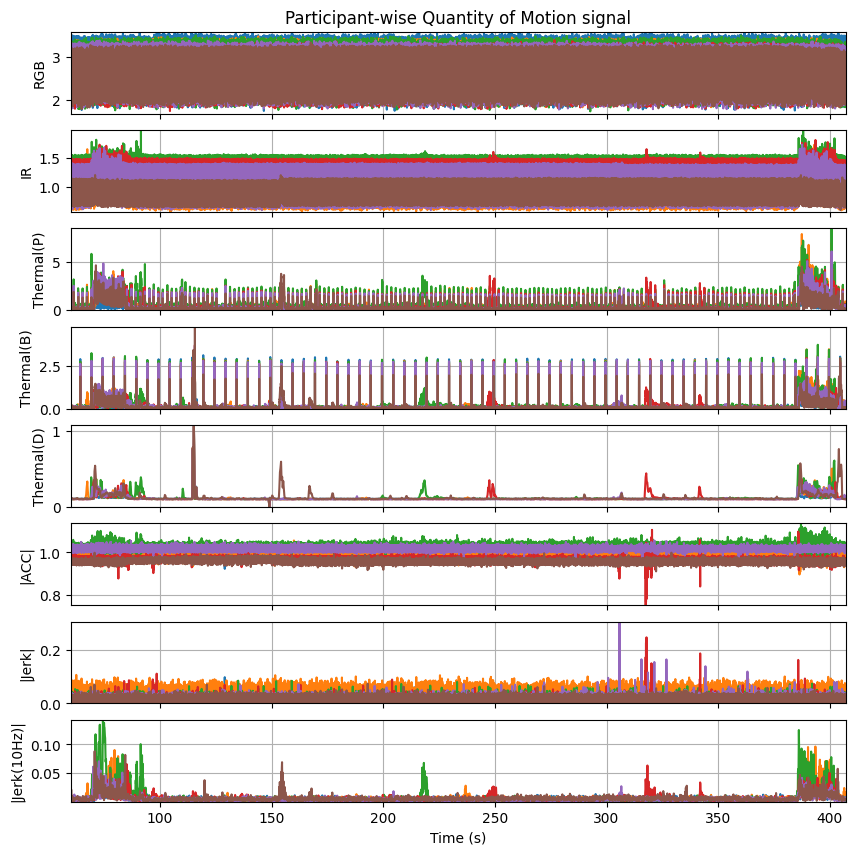

In [31]:
fig,axes = plt.subplots(len(sources),1,figsize=(10,10),sharex=True)
for i in range(len(sources)):
    s = sources[i]
    data = QoMs[s].loc[60:,:]
    data.plot(ax = axes[i],legend=False)
    ymax = data.max().max()
    ymin = data.min().min()

    axes[i].grid()
    axes[i].set(xlim = [60,407],ylabel = source_labels[s],ylim = [ymin,ymax])

axes[0].set(title='Participant-wise Quantity of Motion signal')
axes[i].set(xlabel='Time (s)')
plt.savefig('./plots/'+ 'Initial_QoM_Signals.png',dpi = 100)

plt.show()

In [34]:
out_loc = './Data/Processed/'

smal_files = ['rgb_smal.csv','ir_smal.csv','thermalhandheld_smal.csv','thermalbox_smal.csv','therdata_smal.csv','acc_smal.csv','jerk_smal.csv']
smal_labels = dict(zip(smal_files,['RGB', 'IR', 'Thermal(P)', 'Thermal(B)', 'Thermal(D)','|ACC|','|Jerk|']))


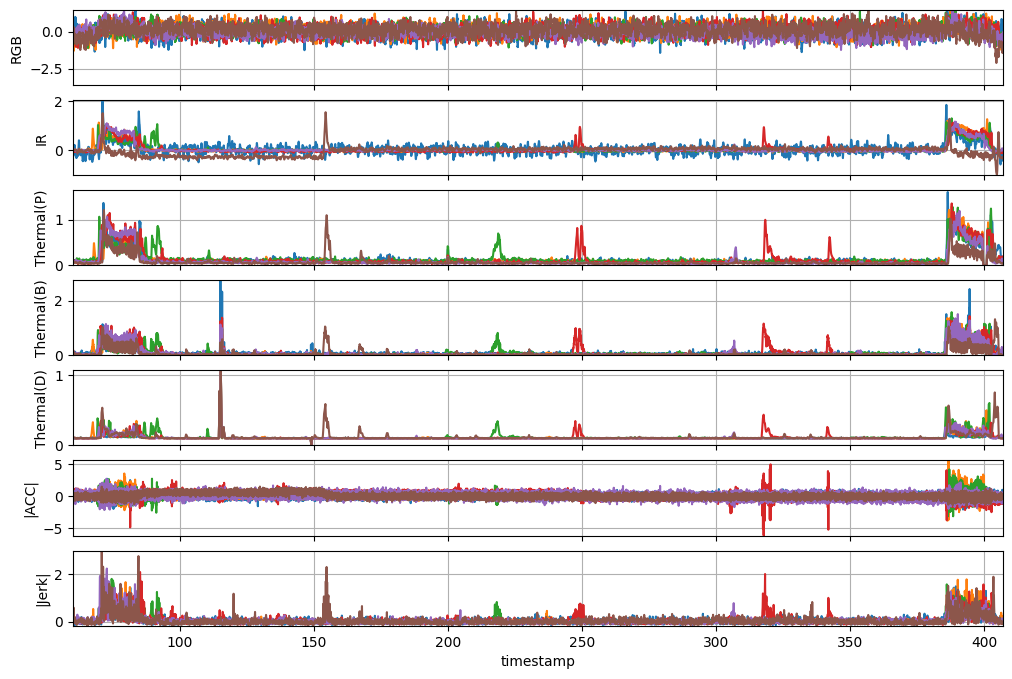

In [35]:
fig,axes = plt.subplots(len(smal_files),1,figsize=(12,len(smal_files)+1),sharex=True)
for i in range(len(smal_files)):
    data = pd.read_csv(out_loc + smal_files[i],index_col=0).loc[60:,:]
    data.plot(ax = axes[i],legend=False)
    ymax = data.max().max()
    ymin = data.min().min()

    axes[i].grid()
    axes[i].set(xlim = [60,407],ylabel = smal_labels[smal_files[i]],ylim = [ymin,ymax])
plt.show()

In [36]:
audio_path = '../Aligned/Audio/'
buff = 0
# audio 
y, sr = librosa.load(audio_path+'Pilot_audio.mp3')
rms =librosa.feature.rms(y=y, frame_length=256, hop_length=64, center=True, pad_mode='constant')
times = librosa.times_like(rms,sr = sr, hop_length=64)
rms_sf = int(sr/64)
aud_df = pd.DataFrame(index = times-1 ) 
aud_df['rms'] = rms[0]
C = librosa.cqt(y=y, sr=sr)
C_db = librosa.amplitude_to_db(np.abs(C), ref=np.max)
times = (-buff+np.arange(len(C_db[0]))*(times[-1])/len(C_db[0])).round(2)
pitchticks = np.arange(7,84,12)
pitchticklabels=['C1','C2','C3','C4','C5','C6','C7']
C_df = pd.DataFrame(data=C_db).transpose()
C_df = C_df[C_df.columns[::-1]]
C_df.set_index(times,inplace = True)
ts = times[0]
te = times[-1]
c1_start = times[0]
c1_end = times[-1]

In [37]:
QoMs = {}
for s in sources:
    Q = pd.read_csv(datapath+s+fileName,index_col = 6)
    QoMs[s] = Q.copy()

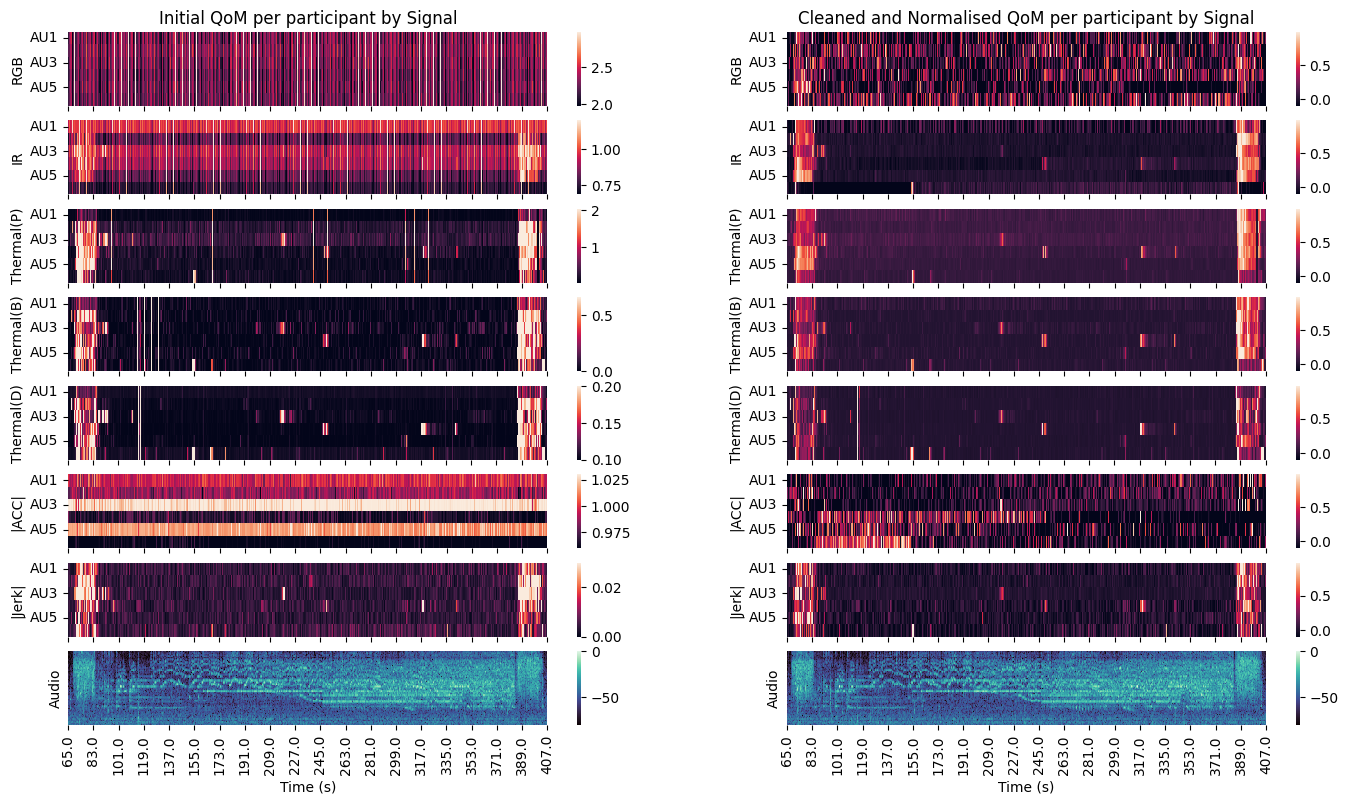

In [43]:
ori_sources = ['rgb','ir','thermalhandheld', 'thermalbox','therdata','acc','jerk_filt10']
samplerates=dict(zip(ori_sources,[59.97,59.97,25,50,4,400,10]))

fig,axes = plt.subplots(8,2,figsize=(17,9))
for i in range(len(ori_sources)):
    data = pd.read_csv(out_loc + ori_sources[i]+'.csv',index_col=0).loc[65:407,:]
    vM= np.round(data.quantile(0.95).quantile(0.8),2)
    vm = np.round(data.quantile(0.05).quantile(0.2),2)
    chart = sns.heatmap(data=data.transpose(),cmap="rocket",vmin=vm, vmax=vM,ax=axes[i,0] ) #vmin=-0.2, vmax=1.00,
    axes[i,0].set(ylabel = smal_labels[smal_files[i]])
    times = data.index
    num_ticks = 20
    xticks = np.linspace(0, len(times) - 1, num_ticks, dtype='int')
    xticklabels = [np.round(times[idx],1) for idx in xticks]
    axes[i,0].set(xticks = xticks,xticklabels= [])
    # if i == len(smal_files)-1: axes[i,0].set(xticks = xticks,xticklabels= xticklabels,xlabel='Time (s)')
    if i == 0:  axes[i,0].set(title='Initial QoM per participant by Signal')
ax = axes[7,0]
chart = sns.heatmap(data=C_df.loc[65:407,:].transpose(), cmap="mako",ax=ax)
times = C_df.loc[65:407,:].index
num_ticks = 20
xticks = np.linspace(0, len(times) - 1, num_ticks, dtype='int')
xticklabels = [np.round(times[idx],1) for idx in xticks]
ax.set(xticks = xticks,yticks=[],xticklabels= xticklabels,xlabel='Time (s)',ylabel='Audio')

for i in range(len(smal_files)):
    data = pd.read_csv(out_loc + smal_files[i],index_col=0).loc[65:407,:]
    chart = sns.heatmap(data=data.transpose(),vmin=-0.1, vmax=0.98,cmap="rocket",ax=axes[i,1])
    axes[i,1].set(ylabel = smal_labels[smal_files[i]],xticklabels=[])
    times = data.index
    num_ticks = 20
    xticks = np.linspace(0, len(times) - 1, num_ticks, dtype='int')
    xticklabels = [np.round(times[idx],1) for idx in xticks]
    axes[i,1].set(xticks = xticks,xticklabels= [])
    # if i == len(smal_files)-1: axes[i,1].set(xticks = xticks,xticklabels= xticklabels,xlabel='Time (s)')
    if i == 0:  axes[i,1].set(title='Cleaned and Normalised QoM per participant by Signal')

ax = axes[7,1]
chart = sns.heatmap(data=C_df.loc[65:407,:].transpose(), cmap="mako",ax=ax)
times = C_df.loc[65:407,:].index
num_ticks = 20
xticks = np.linspace(0, len(times) - 1, num_ticks, dtype='int')
xticklabels = [np.round(times[idx],1) for idx in xticks]
ax.set(xticks = xticks,yticks=[],xticklabels= xticklabels,xlabel='Time (s)',ylabel='Audio')
# fig.tight_layout()

plt.savefig('./plots/'+ 'QoM_Raw_Cleaned.png',dpi = 300)
plt.show()

# Inter QoM 10 Hz

In [6]:
out_loc = './Data/Processed/'
files = os.listdir(out_loc)
files
sources = ['rgb', 'ir', 'thermalhandheld', 'thermalbox', 'therdata','acc','jerk']
source_labels = dict(zip(sources,['RGB', 'IR', 'Thermal(P)', 'Thermal(B)', 'Thermal(D)','ACC','Jerk(10Hz)']))
samplerates=dict(zip(sources,[59.97,59.97,25,50,4,400,10]))
smal_files = ['rgb_smal.csv','ir_smal.csv','thermalhandheld_smal.csv','thermalbox_smal.csv','therdata_smal.csv','acc_smal.csv','jerk_smal.csv']
smal_labels = dict(zip(smal_files,['RGB', 'IR', 'Thermal(P)', 'Thermal(B)', 'Thermal(D)','|ACC|','|Jerk|']))

Convert the measurements to matching values, 10 Hz

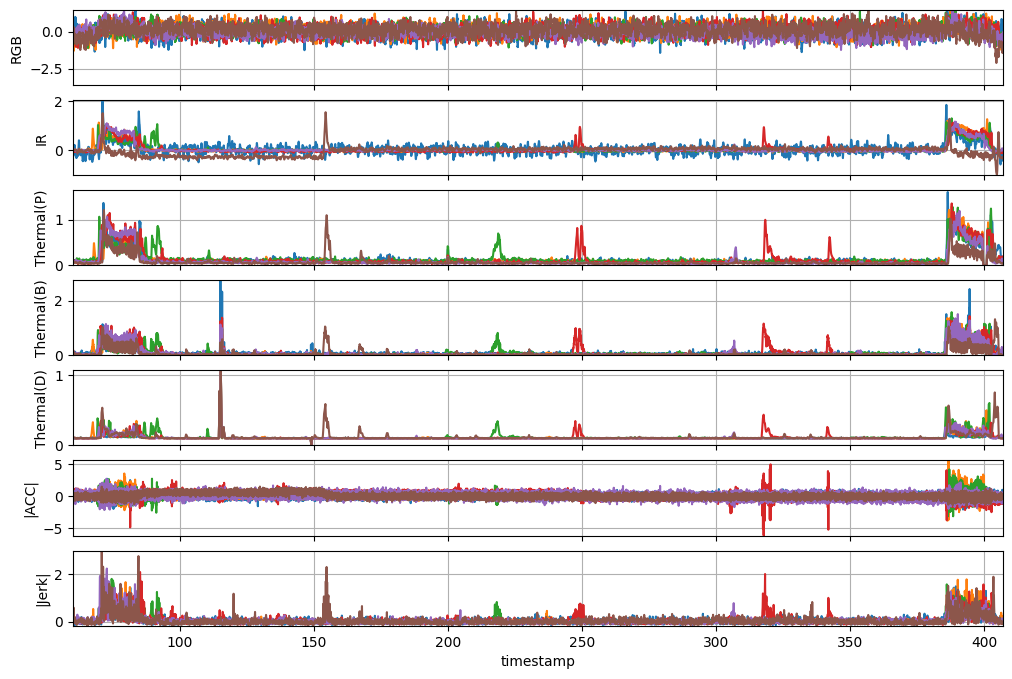

In [7]:
fig,axes = plt.subplots(len(smal_files),1,figsize=(12,len(smal_files)+1),sharex=True)
for i in range(len(smal_files)):
    data = pd.read_csv(out_loc + smal_files[i],index_col=0).loc[60:,:]
    data.plot(ax = axes[i],legend=False)
    ymax = data.max().max()
    ymin = data.min().min()

    axes[i].grid()
    axes[i].set(xlim = [60,407],ylabel = smal_labels[smal_files[i]],ylim = [ymin,ymax])
plt.show()

 # Compare quantity of motion at 10 Hz across all signals
 This is to compare large body motion, not finely timed actions like clapping.

In [8]:
# with clapping
data = pd.read_csv(out_loc + 'jerk_smal.csv',index_col=0).loc[65:407,:]
timestamps = np.array(data.index)
samplerates=[59.97,59.97,25,50,4,400,10]

QoM10 = {}
QoM10coord = pd.DataFrame()
for i in range(len(smal_files)):
    data = pd.read_csv(out_loc + smal_files[i],index_col=0,dtype="float").loc[63:410,:]
    fs = samplerates[i]
    if fs > 10:
        filtering_range = 5 
        cutoff = np.array(filtering_range) #cutoff = np.array([0.05,1]) 
        nyq = 0.5 * fs 
        order = 2 
        normal_cutoff = cutoff / nyq
        b, a = butter(order, normal_cutoff, btype='lowpass', analog=False)
        for col in data.columns:
            data.loc[:,col]=filtfilt(b, a, data.loc[:,col])
    downdata = pd.DataFrame(index = timestamps,columns = data.columns,dtype="float")
    alldata = []
    for col in data.columns:
        f = interpolate.interp1d(data.index,data[col],fill_value='extrapolate',kind='linear')
        v = f(timestamps)
        downdata.loc[:,col] = v
        alldata+=list(v)
    QoM10coord.loc[:,smal_labels[smal_files[i]]] = alldata
    QoM10[smal_labels[smal_files[i]]] = downdata.copy()

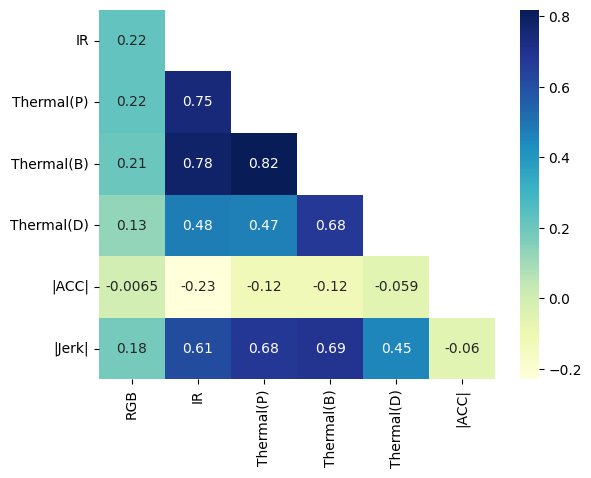

In [14]:
A = QoM10coord.corr(method='pearson')
A = A.iloc[1:,:-1]
mask = np.triu(np.ones_like(A),k=1)
dataplot = sns.heatmap(A, cmap="YlGnBu", annot=True, mask=mask)
plt.show()

In [15]:
# can also evaluate on the subset without clapping, so just the music
data = pd.read_csv(out_loc + 'jerk_smal.csv',index_col=0).loc[80:380,:]
timestamps = np.array(data.index)
samplerates=[59.97,59.97,25,50,4,400,10]

QoM10 = {}
QoM10coord = pd.DataFrame()
for i in range(len(smal_files)):
    data = pd.read_csv(out_loc + smal_files[i],index_col=0,dtype="float").loc[63:410,:]
    fs = samplerates[i]
    if fs > 10:
        filtering_range = 5 
        cutoff = np.array(filtering_range) #cutoff = np.array([0.05,1]) 
        nyq = 0.5 * fs 
        order = 2 
        normal_cutoff = cutoff / nyq
        b, a = butter(order, normal_cutoff, btype='lowpass', analog=False)
        for col in data.columns:
            data.loc[:,col]=filtfilt(b, a, data.loc[:,col])
    downdata = pd.DataFrame(index = timestamps,columns = data.columns,dtype="float")
    alldata = []
    for col in data.columns:
        f = interpolate.interp1d(data.index,data[col],fill_value='extrapolate',kind='linear')
        v = f(timestamps)
        downdata.loc[:,col] = v
        alldata+=list(v)
    QoM10coord.loc[:,smal_labels[smal_files[i]]] = alldata
    QoM10[smal_labels[smal_files[i]]] = downdata.copy()

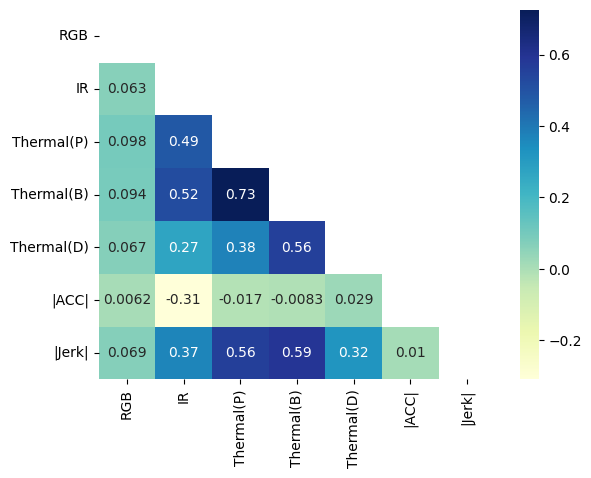

In [16]:
# A = QoM10coord.corr(method='spearman')
B = QoM10coord.corr(method='pearson')

# creating mask
mask = np.triu(np.ones_like(B))

# plotting a triangle correlation heatmap
dataplot = sns.heatmap(B, cmap="YlGnBu", annot=True, mask=mask)

# displaying heatmap
plt.show()

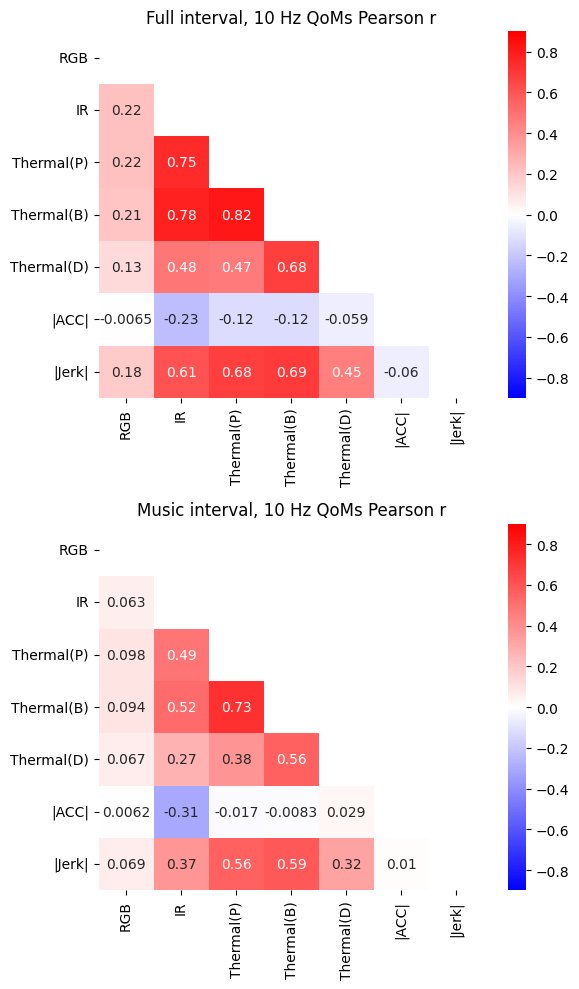

In [32]:
fig,axes = plt.subplots(2,1,figsize=(6,10))

mask = np.triu(np.ones_like(A))
dataplot = sns.heatmap(A, annot=True, mask=mask,ax= axes[0],cmap='bwr',vmin=-0.9,vmax=0.9) #cmap="YlGnBu", 
axes[0].set(title='Full interval, 10 Hz QoMs Pearson r')

mask = np.triu(np.ones_like(B))
dataplot = sns.heatmap(B, annot=True, mask=mask,ax= axes[1],cmap='bwr',vmin=-0.9,vmax=0.9)
axes[1].set(title='Music interval, 10 Hz QoMs Pearson r')
fig.tight_layout()
plt.savefig('./plots/'+ 'Corr_QoM_10Hz.png', dpi = 300)

plt.show()

In [12]:
A = QoM10coord.corr(method='spearman')
A.to_csv('./plots/spearman_10Hz_music.csv')
A.mean()

RGB           0.176588
IR            0.168309
Thermal(P)    0.248226
Thermal(B)    0.294414
Thermal(D)    0.310703
|ACC|         0.099770
|Jerk|        0.215750
dtype: float64

In [13]:
A = QoM10coord.corr(method='pearson')
# A.to_csv('./plots/pearson_10Hz_music.csv')
A.mean()


RGB           0.199687
IR            0.343215
Thermal(P)    0.461095
Thermal(B)    0.496684
Thermal(D)    0.374694
|ACC|         0.101667
|Jerk|        0.417414
dtype: float64

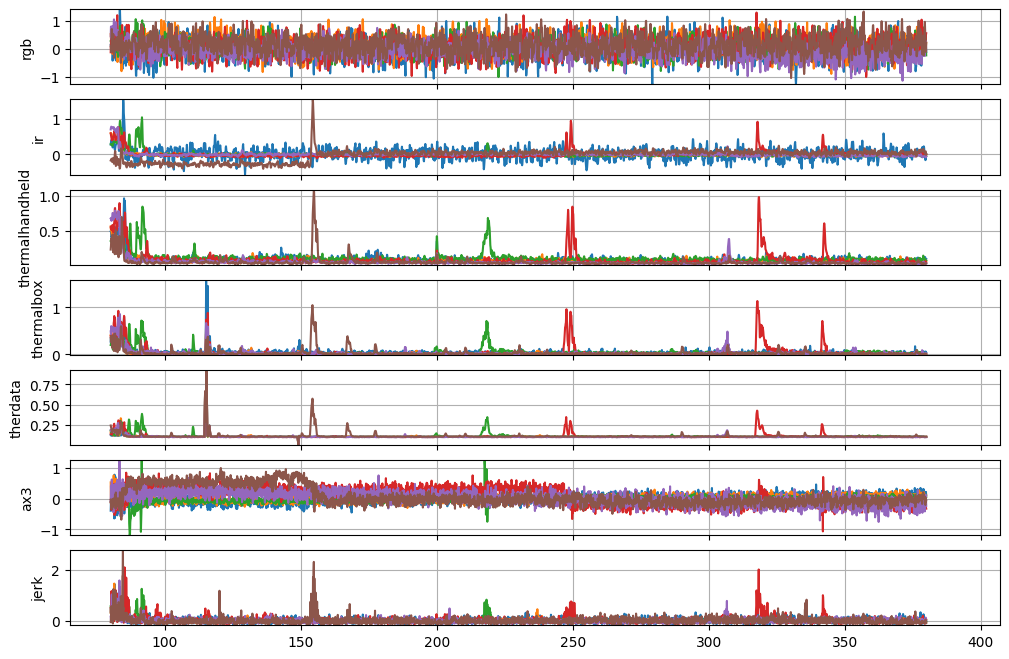

In [14]:
fig,axes = plt.subplots(len(smal_files),1,figsize=(12,len(smal_files)+1),sharex=True)
for i in range(len(smal_files)):
    data = QoM10[smal_labels[smal_files[i]]].copy()
    data.plot(ax = axes[i],legend=False)
    ymax = data.max().max()
    ymin = data.min().min()

    axes[i].grid()
    axes[i].set(xlim = [65,407],ylabel = smal_files[i].split('_')[0],ylim = [ymin,ymax])
plt.show()

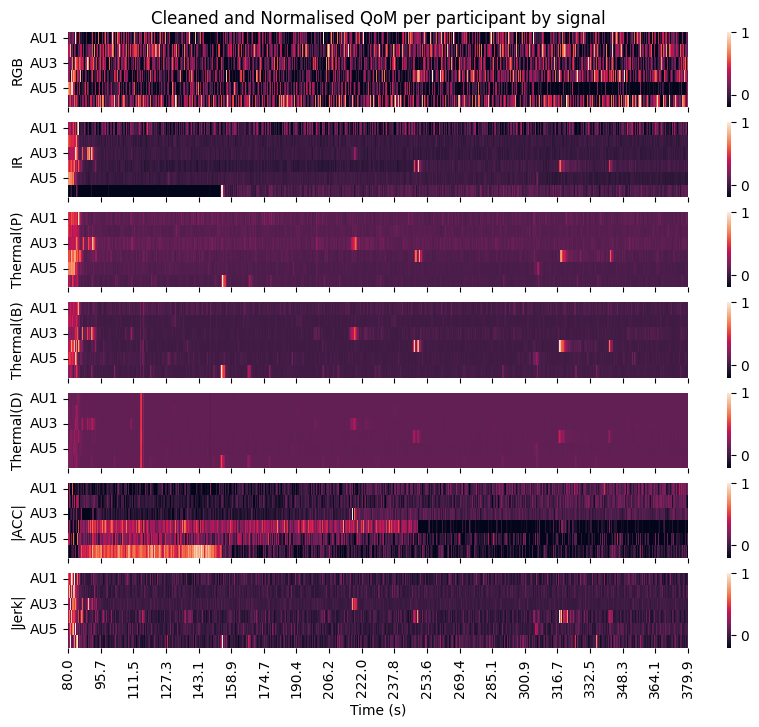

In [15]:
fig,axes = plt.subplots(len(smal_files),1,figsize=(10,len(smal_files)+1))
for i in range(len(smal_files)):
    data = QoM10[smal_labels[smal_files[i]]].loc[65:407,:].copy()
    chart = sns.heatmap(data=data.transpose(),vmin=-0.2, vmax=1.00,cmap="rocket",ax=axes[i])
    axes[i].set(ylabel = smal_labels[smal_files[i]],xticklabels=[])
    times = data.index
    num_ticks = 20
    xticks = np.linspace(0, len(times) - 1, num_ticks, dtype='int')
    xticklabels = [np.round(times[idx],1) for idx in xticks]
    axes[i].set(xticks = xticks,xticklabels= [])
    if i == len(smal_files)-1: axes[i].set(xticks = xticks,xticklabels= xticklabels,xlabel='Time (s)')
    if i == 0:  axes[i].set(title='Cleaned and Normalised QoM per participant by signal')
plt.savefig('./plots/'+ 'Cleaned_Normed_QoM_10Hz.png',dpi = 300)
plt.show()

# Low movement

In [17]:
# with clapping
data = pd.read_csv(out_loc + 'jerk_smal.csv',index_col=0).loc[65:407,:]
timestamps = np.array(data.index)
samplerates=[59.97,59.97,25,50,4,400,10]

QoM10 = {}
QoM10coord = pd.DataFrame()
for i in range(len(smal_files)):
    data = pd.read_csv(out_loc + smal_files[i],index_col=0,dtype="float").loc[63:410,:]
    fs = samplerates[i]
    if fs > 10:
        filtering_range = 5 
        cutoff = np.array(filtering_range) #cutoff = np.array([0.05,1]) 
        nyq = 0.5 * fs 
        order = 2 
        normal_cutoff = cutoff / nyq
        b, a = butter(order, normal_cutoff, btype='lowpass', analog=False)
        for col in data.columns:
            data.loc[:,col]=filtfilt(b, a, data.loc[:,col])
    downdata = pd.DataFrame(index = timestamps,columns = data.columns,dtype="float")
    alldata = []
    for col in data.columns:
        f = interpolate.interp1d(data.index,data[col],fill_value='extrapolate',kind='linear')
        v = f(timestamps)
        downdata.loc[:,col] = v
        alldata+=list(v)
    QoM10coord.loc[:,smal_labels[smal_files[i]]] = alldata
    QoM10[smal_labels[smal_files[i]]] = downdata.copy()

In [34]:
# can also evaluate on the subset without clapping, so just the music
data = pd.read_csv(out_loc + 'jerk_smal.csv',index_col=0).loc[65:407,:]
timestamps = np.array(data.index)
samplerates=[59.97,59.97,25,50,4,400,10]

Low10 = {}
Low10coord = pd.DataFrame()

for i in range(len(smal_files)):
    data = QoM10[smal_labels[smal_files[i]]].loc[63:410,:].rolling(10,center=True).mean().copy()
    data = data.loc[65:407,:].copy()
    data = data.loc[::10,:].copy()
    downdata = data.copy()
    lowthresh=data.quantile(0.33).median()
    for col in data.columns: downdata.loc[data.loc[:,col]>lowthresh,col]= lowthresh
    alldata = []
    for col in downdata.columns:
        alldata+=list(downdata.loc[:,col].values)
    Low10coord.loc[:,smal_labels[smal_files[i]]] = alldata
    Low10[smal_labels[smal_files[i]]] = downdata.copy()
print(len(Low10coord))

2052


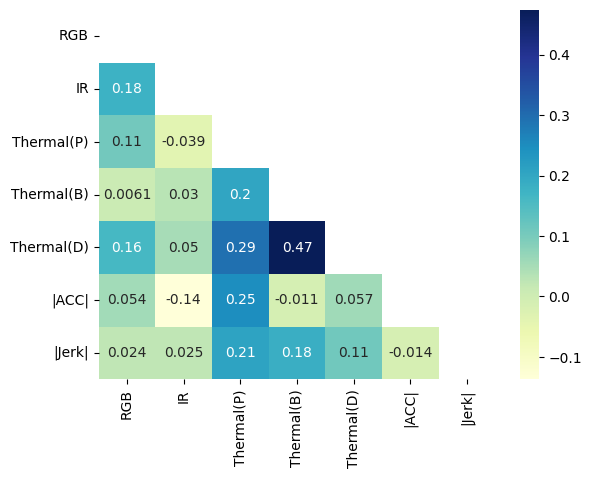

In [35]:
A = Low10coord.corr(method='spearman')
# A = Low10coord.corr(method='pearson')

# creating mask
mask = np.triu(np.ones_like(A))

# plotting a triangle correlation heatmap
dataplot = sns.heatmap(A, cmap="YlGnBu", annot=True, mask=mask)

# displaying heatmap
plt.show()

In [18]:
# can also evaluate on the subset without clapping, so just the music
data = pd.read_csv(out_loc + 'jerk_smal.csv',index_col=0).loc[80:380,:]
timestamps = np.array(data.index)
samplerates=[59.97,59.97,25,50,4,400,10]
timestamps = np.array(data.index)

Low10 = {}
Low10all = pd.DataFrame()

for i in range(len(smal_files)):
    data = QoM10[smal_labels[smal_files[i]]].loc[80:380,:].rolling(10,center=True).mean().copy()
    data = data.loc[::10,:].copy()
    downdata = data.copy()
    lowthresh=data.quantile(0.33).median()
    for col in data.columns: downdata.loc[data.loc[:,col]>lowthresh,col]= lowthresh
    alldata = []
    for col in data.columns:
        alldata+=list(downdata.loc[:,col].values)
    Low10all.loc[:,smal_labels[smal_files[i]]] = alldata
    Low10[smal_labels[smal_files[i]]] = downdata.copy()
print(len(Low10all))

1800


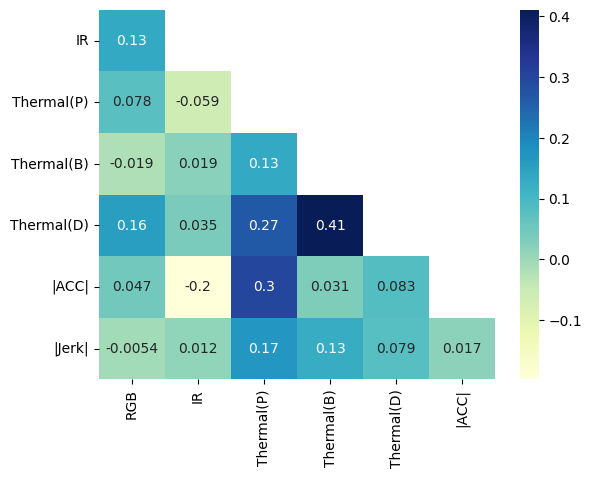

In [22]:
B = Low10all.corr(method='spearman')
B = B.iloc[1:,:-1]
mask = np.triu(np.ones_like(B),k=1)
dataplot = sns.heatmap(B, cmap="YlGnBu", annot=True, mask=mask)
plt.show()

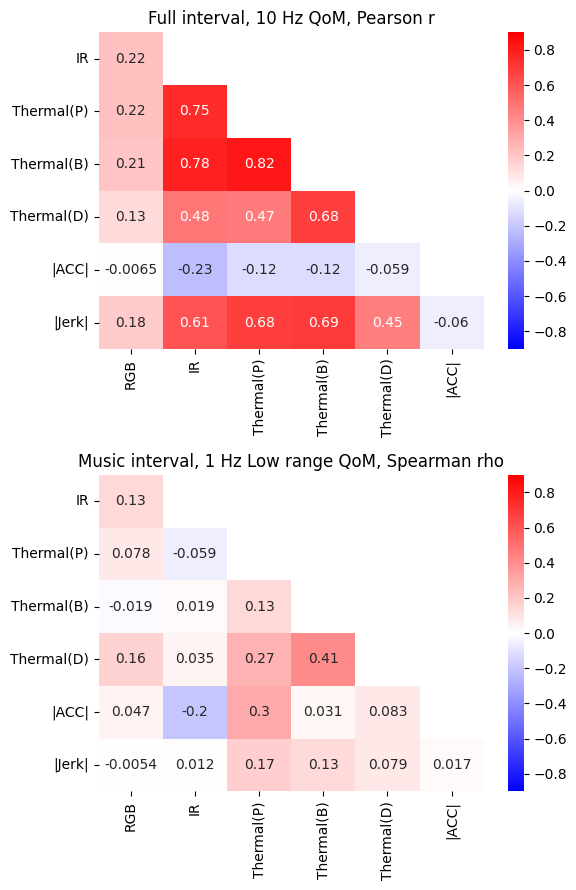

In [26]:
fig,axes = plt.subplots(2,1,figsize=(6,9))

dataplot = sns.heatmap(A, annot=True, mask=mask,ax= axes[0],cmap='bwr',vmin=-0.9,vmax=0.9) #cmap="YlGnBu", 
axes[0].set(title='Full interval, 10 Hz QoM, Pearson r')

dataplot = sns.heatmap(B, annot=True, mask=mask,ax= axes[1],cmap='bwr',vmin=-0.9,vmax=0.9)
axes[1].set(title='Music interval, 1 Hz Low range QoM, Spearman rho')
fig.tight_layout()
plt.savefig('./plots/'+ 'Corr_QoMs.png',dpi = 300)

plt.show()

For reference, on these downsampled measurements (1 Hz), the rho value of around 0.1 is near a pvalue of 0.01. The thermal measurements agree the most, while the accelerometer, IR, and RBG measurements are comparably muddy. This suggests that capturing a clear lack of motion with any one of the systems is a challenge. .

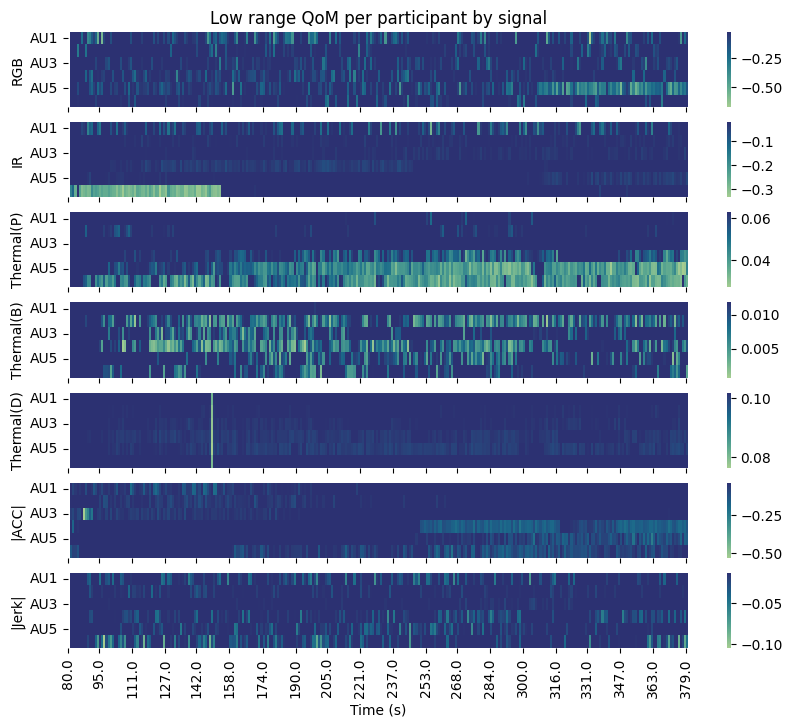

In [114]:
# catch more or less stillness
fig,axes = plt.subplots(len(smal_files),1,figsize=(10,len(smal_files)+1))
low_data = []
for i in range(len(smal_files)):
    data = Low10[smal_labels[smal_files[i]]].loc[65:407,:].copy()
    chart = sns.heatmap(data=data.transpose(),cmap="crest",ax=axes[i])
    axes[i].set(ylabel = smal_labels[smal_files[i]],xticklabels=[])
    times = data.index
    num_ticks = 20
    xticks = np.linspace(0, len(times) - 1, num_ticks, dtype='int')
    xticklabels = [np.round(times[idx],1) for idx in xticks]
    axes[i].set(xticks = xticks,xticklabels= [])
    if i == len(smal_files)-1: axes[i].set(xticks = xticks,xticklabels= xticklabels,xlabel='Time (s)')
    if i == 0:  axes[i].set(title='Low range QoM per participant by signal')
plt.savefig('./plots/'+ 'Low_QoM_1Hz.png',dpi = 300)
plt.show()

These moments of less motion are not without any agreement between systems, but performance is not convernent.

In [83]:
import pingouin as pg

In [94]:
for col in Low10all.columns:
    for col2 in Low10all.columns:
        print([col,col2])
        print(pg.corr(Low10all[col], Low10all[col2], method='spearman'))

['RGB', 'RGB']
             n    r       CI95%  p-val  power
spearman  1794  1.0  [1.0, 1.0]    0.0      1
['RGB', 'IR']
             n         r         CI95%         p-val     power
spearman  1794  0.134559  [0.09, 0.18]  1.056479e-08  0.999919
['RGB', 'Thermal(P)']
             n         r         CI95%     p-val     power
spearman  1794  0.077679  [0.03, 0.12]  0.000992  0.909045
['RGB', 'Thermal(B)']
             n         r          CI95%     p-val     power
spearman  1794 -0.019073  [-0.07, 0.03]  0.419449  0.127376
['RGB', 'Thermal(D)']
             n         r        CI95%         p-val     power
spearman  1794  0.156104  [0.11, 0.2]  2.969471e-11  0.999999
['RGB', '|ACC|']
             n         r          CI95%     p-val     power
spearman  1794  0.017924  [-0.03, 0.06]  0.448019  0.118113
['RGB', '|Jerk| ']
             n         r          CI95%     p-val     power
spearman  1794 -0.005418  [-0.05, 0.04]  0.818623  0.056038
['IR', 'RGB']
             n         r         CI

In [92]:
Low10all.columns

Index(['RGB', 'IR', 'Thermal(P)', 'Thermal(B)', 'Thermal(D)', '|ACC|',
       '|Jerk| '],
      dtype='object')